In [5]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
# import import_ipynb
from scipy.interpolate import PchipInterpolator
# import seaborn as sns

def interpolador(subject, method, size):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    data = subject
    x = np.arange(len(data))
    
    # Crear 'size' puntos equidistantes
    x_new = np.linspace(0, len(data) - 1, size*(len(data)-1) + len(data))
    
    if method == 'lineal':
        data_interp = np.interp(x_new, x, data)
    elif method == 'herm':
        interpolator = PchipInterpolator(x, data)
        data_interp = interpolator(x_new)
    
    return x_new, data_interp

def interpolador_constante(subject):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    x = np.arange(2)
    data_interp = np.array([])
    diferencias =np.abs(np.diff(subject))
    if (np.max(diferencias) - np.min(diferencias)) <= 1e-5:
        return subject
    diferencias_sin_0 = diferencias[diferencias != 0]
    diferencias = np.round(diferencias/np.min(diferencias_sin_0))
    for i in range(len(subject)-1):
        data = subject[i:i+2]
        if diferencias[i] == 0:
            data_interp = np.concatenate((data_interp,data[:-1]))
            continue
        size = int(diferencias[i])- 1
        # Crear 'size' puntos equidistantes
        x_new = np.linspace(0, 1, size + 2)
        interp_step = np.interp(x_new, x, data)
        data_interp = np.concatenate((data_interp,interp_step[:-1]))
    data_interp = np.concatenate((data_interp,np.array([data[-1]])))

    return data_interp

def discretizar(array, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    window = (np.abs(np.min(array)) + np.abs(np.max(array)))/(num_partitions - 1)
    discretizador = [np.min(array)+window*(i) for i in range(num_partitions)]
    if discretizador[len(discretizador)-1] != np.max(array):
        discretizador[len(discretizador)-1] = np.max(array)
    array_discreto = []
    for i,valor in enumerate(array):
        array_discreto.append(min(discretizador, key=lambda x: abs(x - valor)))

    return array_discreto

def discretizar_x(array_y, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    array_x = range(int(len(array_y)))
    window = (len(array_x))/(num_partitions - 1)
    x_discreto = [int(window*(i)) for i in range(num_partitions)]
    array_discreto = []
    for i in x_discreto[0:len(x_discreto)-1]:
        array_discreto.append(array_y[i])
    array_discreto.append(array_y[len(array_x)-1])

    return x_discreto, array_discreto

def arm_detector(data, num_ventanas=25, b=0.6):
    n = len(data)
    x = np.arange(n)
    
    # Calcular el tamaño de cada ventana
    window_size = n // num_ventanas

    # Lista para almacenar los porcentajes de puntos dentro de las regiones
    porcentajes = []

    # Ajustar y graficar el ajuste lineal por cada ventana con las líneas paralelas
    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]
        
        # Crear y ajustar el modelo de regresión lineal
        modelo = LinearRegression()
        modelo.fit(x_window, y_window)
        
        # Obtener la pendiente y la intersección de la recta ajustada
        pendiente = modelo.coef_[0]
        interseccion = modelo.intercept_
        
        # Predecir valores ajustados
        y_pred = modelo.predict(x_window)
                
        # Calcular las rectas paralelas desplazadas por 'b'
        y_paralela_superior = pendiente * x_window + (interseccion + b)
        y_paralela_inferior = pendiente * x_window + (interseccion - b)
                
        # Calcular el porcentaje de datos dentro de la región delimitada por las líneas paralelas
        dentro_region = np.sum((y_window >= y_paralela_inferior.flatten()) & (y_window <= y_paralela_superior.flatten()))
        fuera_region = len(y_window) - dentro_region
        
        # Calcular el porcentaje de datos dentro de la región respecto a los datos fuera de la región
        porcentaje = (dentro_region * 100)/(dentro_region + fuera_region)
        porcentajes.append(porcentaje)

    def indice_mayor_90(arr):
        n = len(arr)
    
        # Revisar cada índice para encontrar el primero que cumpla la condición
        for i in range(n):
            if np.all(arr[i:] > 80) and len(arr[i:]) > 4:
                return i
        # Si no hay tal índice, regresar el último índice
        return n - 1
    
    indice = indice_mayor_90(np.array(porcentajes))*window_size
    return indice

def J_univariante(X, tau=1, corte=False):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def J_bivariante(X, Y, corte=False):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X
    y1 = Y
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def generar_uniforme_centrada(n, varianza):
    # Calcular el límite superior e inferior de la distribución uniforme
    limite = np.sqrt(varianza) # varianza*3
    # Generar n números aleatorios con distribución uniforme entre -limite y limite
    return np.random.uniform(-limite, limite, n)

def lyapunov_exponent_from_henon_orbit(xs, ys, a, b):
    # Vectores de perturbación iniciales
    v1, v2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])  

    sum_ln1, sum_ln2 = 0.0, 0.0  # Sumas para los exponentes de Lyapunov
    n = len(xs)
    
    for i in range(n):
        # Derivadas parciales del mapa de Henon
        dfdx = -2 * a * xs[i]
        dfdy = 1
        dgdx = b
        dgdy = 0
        
        # Matriz jacobiana del mapa de Henon
        J = np.array([[dfdx, dfdy],
                      [dgdx, dgdy]])
        
        # Aplicar la matriz jacobiana a los vectores de perturbación
        v1 = np.dot(J, v1)
        v2 = np.dot(J, v2)

        # Gram-Schmidt ortogonalización
        v1_norm = np.linalg.norm(v1)
        v1 = v1 / v1_norm
        
        v2_proj = np.dot(v1, v2) * v1  # Proyección de v2 sobre v1
        v2 = v2 - v2_proj
        v2_norm = np.linalg.norm(v2)
        v2 = v2 / v2_norm
        
        # Actualizar las sumas de los logaritmos de los cocientes
        sum_ln1 += np.log(v1_norm)
        sum_ln2 += np.log(v2_norm)

    # Cálculo de los exponentes de Lyapunov
    le1 = sum_ln1 / n
    le2 = sum_ln2 / n

    return max(le1, le2)

def brownian_bridge(t0, tT, x0, xT, n_steps):
    t = np.linspace(t0, tT, n_steps)
    #Generar movimiento browniano con media cero
    W = np.random.normal(0, np.sqrt(t[1] - t[0]), size=n_steps-1)
    W = np.insert(np.cumsum(W), 0, 0)  # Inserta W(0) = 0 y suma acumulativa
    # Interpolación del Brownian Bridge
    X = x0 + (t - t0) / (tT - t0) * (xT - x0) + W - (t - t0) / (tT - t0) * W[-1]
    return t, X

def interpolador_estocastico(s_0_discreto, n_steps):
    t_list, X_list = [], []
    for i in range(len(s_0_discreto)- 1):
        t0 = i
        tT = i+1
        x0 = s_0_discreto[i]
        xT = s_0_discreto[i+1]
        t, X = brownian_bridge(t0, tT, x0, xT, n_steps)
        t_list = np.concatenate((t_list, t))
        X_list = np.concatenate((X_list, X))
    return X_list

def replace_long_repeating_segments(data, tolerance=1e-1):
    """
    Reemplaza segmentos largos de valores repetidos en los datos con un puente browniano,
    permitiendo un margen de tolerancia para determinar si los valores son similares.
    
    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores como repetidos.
        
    Returns:
        list: Array con los segmentos largos reemplazados por un puente browniano.
    """
    result = []
    n = len(data)
    i = 0
    
    while i < n:
        start = i
        # Detectar si hay un segmento repetido dentro del margen de tolerancia
        while i < n - 1 and abs(data[i] - data[i + 1]) <= tolerance:
            i += 1
        
        segment_length = i - start + 1
        
        if segment_length > 2:  # Si el segmento tiene más de dos puntos repetidos
            result.append(data[start])  # Mantener el primer valor
            x0 = data[start]
            xT = data[i]
            t0, tT = 0, 1  # Intervalo estándar para el puente browniano
            
            # Generar los puntos interpolados con el puente browniano
            _, bridge = brownian_bridge(t0, tT, x0, xT, segment_length)
            result.extend(bridge[1:-1])  # Añadir los puntos generados (sin el primero ni el último)
            result.append(data[i])  # Mantener el último valor
        else:
            # Si hay uno o dos puntos repetidos, se añaden tal como están
            result.extend(data[start:i + 1])
        
        i += 1
    
    return result

def remove_consecutive_duplicates(data, tolerance=1e-1):
    """
    Remueve duplicados consecutivos en los datos con un margen de tolerancia.

    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores similares.

    Returns:
        list: Array con duplicados consecutivos removidos.
    """
    if not data:
        return []

    result = [data[0]]  # Comenzamos con el primer elemento
    for i in range(1, len(data)):
        if abs(data[i] - data[i - 1]) > tolerance:
            result.append(data[i])

    return np.array(result)

def derivada_index(array):
    array = np.asarray(array)
    derivada = np.abs(np.diff(array))  # Calcula la diferencia entre puntos subsecuentes
    return derivada

def mean_d(array):
    distancias = np.abs(np.diff(array))
    return np.mean(distancias)

def create_periodos_logistic():
    periodos_logistic = []
    with open("logistic_map\periodos_logistic.txt", "r") as file:
        for line in file:
            # Convertir cada línea a su tipo adecuado (número o cadena)
            line = line.strip()  # Eliminar saltos de línea o espacios extra
            if line.replace(".", "", 1).isdigit():  # Verifica si es un número (enteros o flotantes)
                if "." in line:
                    periodos_logistic.append(float(line))  # Si tiene punto, es flotante
                else:
                    periodos_logistic.append(int(line))  # Si no, es entero
            else:
                periodos_logistic.append(line)  # Si no es número, es una cadena
periodos_logistic = create_periodos_logistic

def detect_per(Xn, tolerancia=1e-6, max_periodo=100):
    """
    Detecta si Xn está en un régimen periódico y calcula la varianza por punto fijo.
    Si el sistema es caótico, devuelve una lista con una varianza igual a 1.
    
    Parámetros:
        Xn (array): Secuencia del mapa logístico.
        tolerancia (float): Tolerancia para determinar igualdad de puntos.
        max_periodo (int): Máximo periodo a buscar.
    
    Retorna:
        dict: Contiene información sobre el régimen y las varianzas calculadas.
    """
    n = len(Xn)
    for periodo in range(1, max_periodo + 1):
        es_periodico = True
        for i in range(n - periodo):
            if abs(Xn[i] - Xn[i + periodo]) > tolerancia:
                es_periodico = False
                break
        if es_periodico:
            # Calcular las varianzas para cada punto fijo del ciclo
            puntos_fijos = [Xn[i::periodo] for i in range(periodo)]
            varianzas = [np.var(punto_fijo) for punto_fijo in puntos_fijos]
            # print(f"regimen: periodico-{periodo}, varianzas: {varianzas}")
            return periodo
    
    # Si no se encuentra un periodo, considerar el régimen caótico
    # print("regimen: caotico, varianzas: 1")
    return "Caos"

def var_per_state(Xn,N):
    """
    Divide Xn en N arrays, donde cada uno contiene un punto fijo del periodo.
    
    Parámetros:
        Xn (array): Secuencia del mapa logístico.
        N (int): Número de periodo.
    
    Retorna:
        list: Lista de N arrays, cada uno con un punto fijo del ciclo.
    """
    # N = detect_per(Xn)
    # print(N)
    if N == "Caos":
        return "Caos"
    if N <= 0:
        raise ValueError("El número de periodo debe ser mayor que 0.")
    if len(Xn) < N:
        raise ValueError("El tamaño del array es menor que el número de periodo.")
    
    puntos_fijos = [Xn[i::N] for i in range(N)]
    # for p in puntos_fijos:
        # print(p[:20])
    varianza = [np.var(arr) for arr in puntos_fijos]
    # print(np.array(varianza) - [8.011868568650901e-32, 1.5407439555097887e-32])

        # return np.sum(varianza)/len(varianza)
    return varianza



<>:380: SyntaxWarning: invalid escape sequence '\p'
<>:380: SyntaxWarning: invalid escape sequence '\p'
C:\Users\MILEG\AppData\Local\Temp\ipykernel_16584\763281151.py:380: SyntaxWarning: invalid escape sequence '\p'
  with open("logistic_map\periodos_logistic.txt", "r") as file:


In [3]:
import numpy as np

A = np.array([[0, 1], [-1, 0]])
B = np.array([1,2])
np.dot(A,B)

array([ 2, -1])

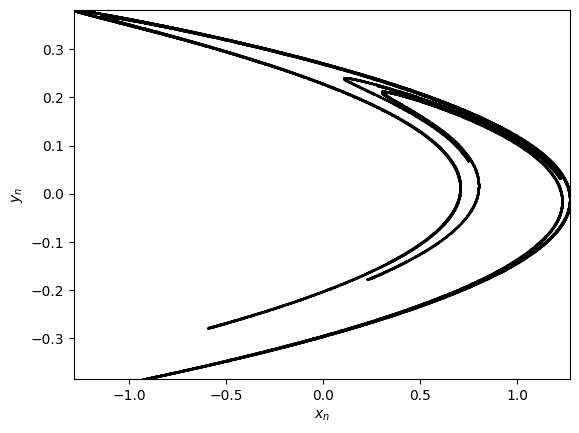

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def henon_map(a=1.4, b=0.3, x0=0.1, y0=0.0, n_iter=100000, discard=1000):
    """
    Genera puntos del atractor de Hénon.
    
    Parámetros:
    -----------
    a, b : float
        Parámetros del mapa de Hénon.
    x0, y0 : float
        Condiciones iniciales.
    n_iter : int
        Número de iteraciones totales.
    discard : int
        Iteraciones iniciales descartadas (transitorio).
    
    Devuelve:
    ---------
    x, y : arrays de float
        Coordenadas de los puntos en el atractor.
    """
    x = np.zeros(n_iter)
    y = np.zeros(n_iter)
    x[0], y[0] = x0, y0

    for i in range(1, n_iter):
        x[i] = 1 - a * x[i-1]**2 + y[i-1]
        y[i] = b * x[i-1]

    return x[discard:], y[discard:]

# Parámetros ajustables
a = 1.4
b = 0.3

# Generar puntos
x, y = henon_map(a=a, b=b, x0=0.1, y0=0.0, n_iter=100000, discard=1000)

# Graficar espacio de fase
# plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=0.1, color="black", alpha=0.6)
# plt.title(f"Atractor de Hénon (a={a}, b={b})")
plt.xlabel("$x_n$")
plt.xlim(np.min(x),np.max(x))
plt.ylim(np.min(y),np.max(y))
plt.ylabel("$y_n$")
# plt.axis("equal")
# plt.tight_layout()
plt.show()


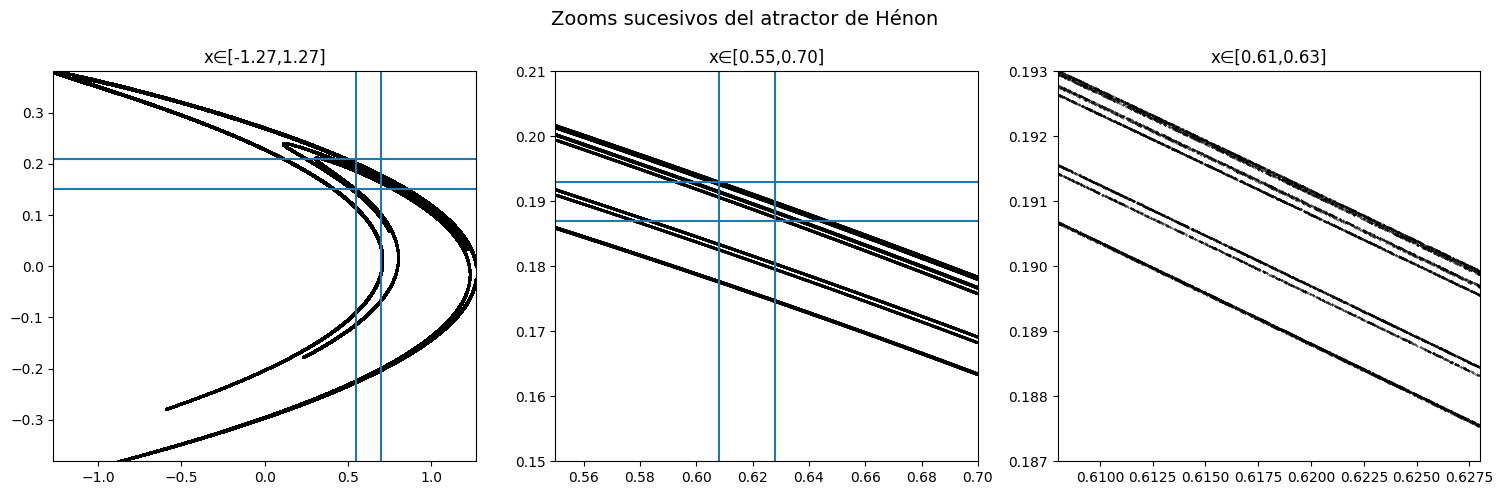

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def henon_map(a=1.4, b=0.3, x0=0.1, y0=0.0, n_iter=10000000, discard=1000):
    x = np.zeros(n_iter)
    y = np.zeros(n_iter)
    x[0], y[0] = x0, y0
    for i in range(1, n_iter):
        x[i] = 1 - a * x[i-1]**2 + y[i-1]
        y[i] = b * x[i-1]
    return x[discard:], y[discard:]

# Generar atractor con alta resolución
x, y = henon_map(n_iter=5_000_000, discard=2000)

# Definir niveles de zoom automáticos
zoom_levels = [
    (np.percentile(x, 1), np.percentile(x, 99),
     np.percentile(y, 1), np.percentile(y, 99)),
    (0.55,0.7, 0.15, 0.21),  # Zoom manual en región densa
    (0.608, 0.628, 0.187, 0.193)   # Zoom más profundo
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i , ax, (xmin, xmax, ymin, ymax) in zip([0,1,0],axes, zoom_levels):
    future = zoom_levels[i+1]
    mask = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
    ax.scatter(x[mask], y[mask], s=0.1, c="black")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axvline(x = future[0])
    ax.axvline(x = future[1])
    ax.axhline(y = future[2])
    ax.axhline(y = future[3])
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_title(f"x∈[{xmin:.2f},{xmax:.2f}]")
plt.suptitle("Zooms sucesivos del atractor de Hénon", fontsize=14)
plt.tight_layout()
plt.show()


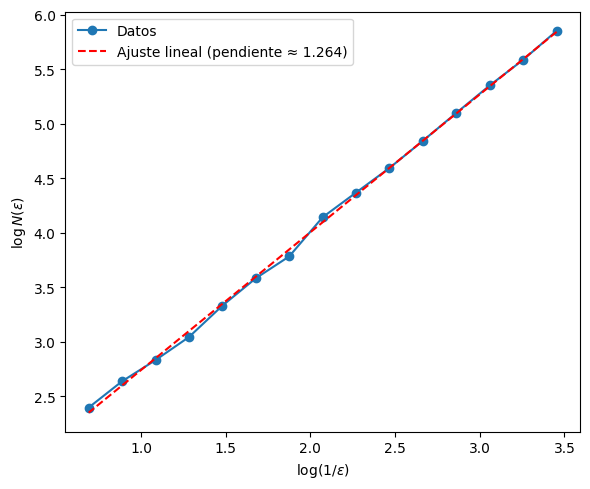

Dimensión fractal estimada: D ≈ 1.264


In [57]:
def box_counting_dimension(x, y, n_scales=15):
    # Definir caja que contiene el atractor
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)

    Ns = []
    epsilons = np.logspace(-1.5, -0.3, n_scales)  # escalas logarítmicas

    for eps in epsilons:
        # número de cajas en cada eje
        nx = int(np.ceil((xmax - xmin) / eps))
        ny = int(np.ceil((ymax - ymin) / eps))
        # cajas ocupadas
        boxes = set()
        for xi, yi in zip(x, y):
            ix = int((xi - xmin) / eps)
            iy = int((yi - ymin) / eps)
            boxes.add((ix, iy))
        Ns.append(len(boxes))

    return epsilons, np.array(Ns)

epsilons, Ns = box_counting_dimension(x, y)

# Gráfica log-log
log_eps = np.log(1/epsilons)
log_N = np.log(Ns)
coeffs = np.polyfit(log_eps, log_N, 1)
D = coeffs[0]  # pendiente = dimensión fractal

plt.figure(figsize=(6,5))
plt.plot(log_eps, log_N, 'o-', label="Datos")
plt.plot(log_eps, np.polyval(coeffs, log_eps), 'r--',
         label=f"Ajuste lineal (pendiente ≈ {D:.3f})")
plt.xlabel(r"$\log(1/\varepsilon)$")
plt.ylabel(r"$\log N(\varepsilon)$")
# plt.title("Cálculo de dimensión fractal (Box-Counting)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Dimensión fractal estimada: D ≈ {D:.3f}")


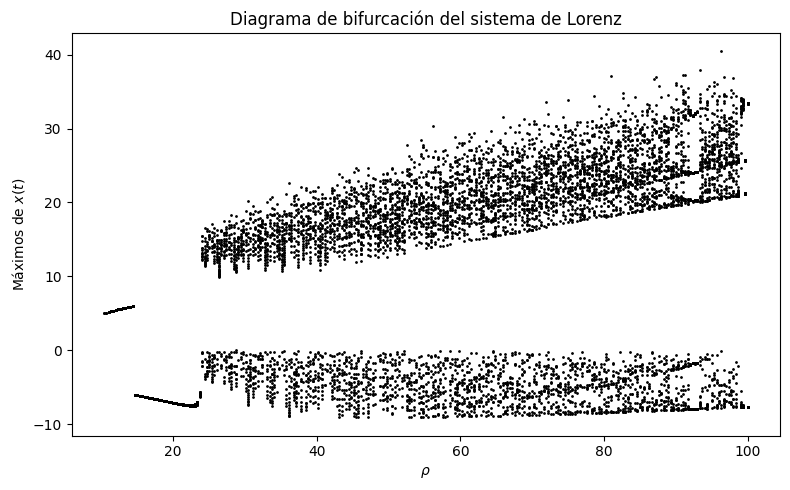

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lorenz_rhs(state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def rk4_step(state, dt, sigma, rho, beta):
    k1 = lorenz_rhs(state, sigma, rho, beta)
    k2 = lorenz_rhs(state + 0.5*dt*k1, sigma, rho, beta)
    k3 = lorenz_rhs(state + 0.5*dt*k2, sigma, rho, beta)
    k4 = lorenz_rhs(state + dt*k3, sigma, rho, beta)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def bifurcation_lorenz(rhos, dt=0.01, t_trans=50, t_sample=20,
                       sigma=10, beta=8/3, x0=1, y0=1, z0=1):
    results_rho = []
    results_x = []
    for rho in rhos:
        state = np.array([x0, y0, z0], dtype=float)
        n_trans = int(t_trans/dt)
        n_sample = int(t_sample/dt)
        # integrar transitorio
        for _ in range(n_trans):
            state = rk4_step(state, dt, sigma, rho, beta)

        # muestreo de máximos de x
        x_vals = []
        prev = state[0]
        for _ in range(n_sample):
            new_state = rk4_step(state, dt, sigma, rho, beta)
            if state[0] > prev and state[0] > new_state[0]:
                # máximo local detectado
                x_vals.append(state[0])
            prev = state[0]
            state = new_state

        results_rho.extend([rho]*len(x_vals))
        results_x.extend(x_vals)
    return np.array(results_rho), np.array(results_x)

# === Generar el diagrama ===
rhos = np.linspace(0, 100, 300)  # rango de ρ
r, x_max = bifurcation_lorenz(rhos)

plt.figure(figsize=(8, 5))
plt.scatter(r, x_max, s=1, color="black")
plt.xlabel(r"$\rho$")
plt.ylabel(r"Máximos de $x(t)$")
plt.title("Diagrama de bifurcación del sistema de Lorenz")
plt.tight_layout()
plt.show()


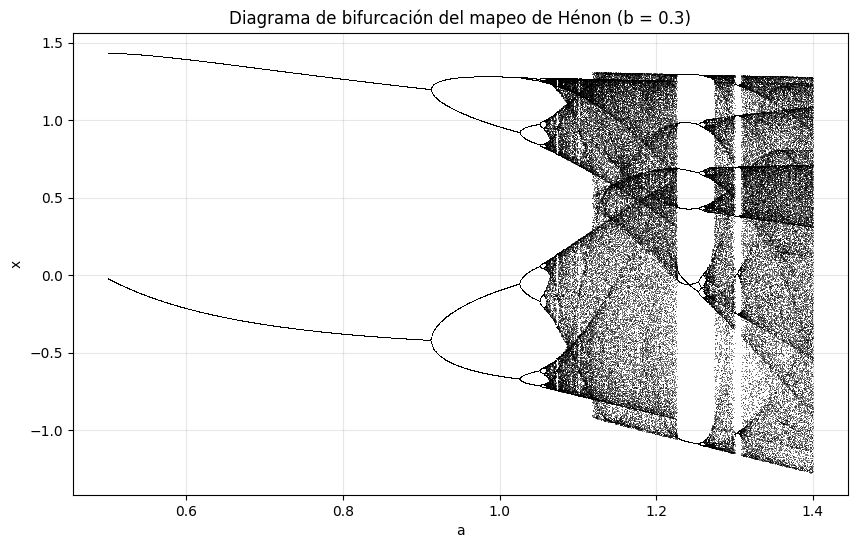

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def henon_map(a, b, x0=0.1, y0=0.1, n_trans=1000, n_points=200):
    """
    Genera puntos del mapeo de Hénon para un valor de a.
    :param a: parámetro a del mapeo
    :param b: parámetro b del mapeo
    :param x0, y0: condiciones iniciales
    :param n_trans: iteraciones de transitorio a descartar
    :param n_points: número de puntos a guardar después del transitorio
    :return: listas con los valores de x después del transitorio
    """
    x, y = x0, y0
    # Transitorio
    for _ in range(n_trans):
        x, y = 1 - a * x * x + y, b * x

    # Iteraciones para graficar
    xs = []
    for _ in range(n_points):
        x, y = 1 - a * x * x + y, b * x
        xs.append(x)

    return xs

# Parámetros
b = 0.3
a_values = np.linspace(0.5, 1.4, 2000)  # rango de a
x_data = []
a_data = []

for a in a_values:
    xs = henon_map(a, b)
    x_data.extend(xs)
    a_data.extend([a] * len(xs))

# Graficar diagrama de bifurcación
plt.figure(figsize=(10, 6))
plt.plot(a_data, x_data, ',k', alpha=0.5)  # ',k' usa puntos muy pequeños en negro
plt.xlabel("a")
plt.ylabel("x")
plt.title(f"Diagrama de bifurcación del mapeo de Hénon (b = {b})")
plt.grid(alpha=0.3)
plt.show()


1.0
1.0020100502512563
1.0040201005025127
1.0060301507537688
1.0080402010050251
1.0100502512562815
1.0120603015075378
1.014070351758794
1.0160804020100502
1.0180904522613066
1.020100502512563
1.022110552763819
1.0241206030150753
1.0261306532663317
1.028140703517588
1.0301507537688441
1.0321608040201005
1.0341708542713568
1.0361809045226131
1.0381909547738692
1.0402010050251256
1.042211055276382
1.0442211055276382
1.0462311557788944
1.0482412060301507
1.050251256281407
1.0522613065326634
1.0542713567839197
1.0562814070351758
1.0582914572864321
1.0603015075376885
1.0623115577889448
1.064321608040201
1.0663316582914573
1.0683417085427136
1.07035175879397
1.072361809045226
1.0743718592964824
1.0763819095477387
1.078391959798995
1.0804020100502512
1.0824120603015075
1.0844221105527638
1.0864321608040202
1.0884422110552763
1.0904522613065326
1.092462311557789
1.0944723618090453
1.0964824120603014
1.0984924623115577
1.100502512562814
1.1025125628140704
1.1045226130653267
1.1065326633165828
1.

C:\Users\MILEG\AppData\Local\Temp\ipykernel_16584\359485265.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


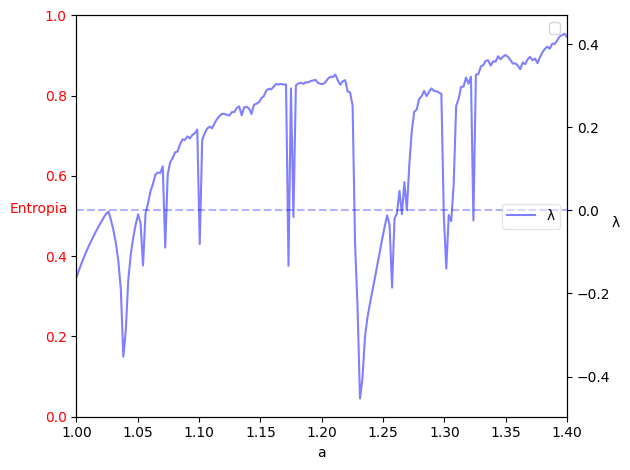

In [10]:
def henon_map(a, b, n, trans=200):
    total = n + trans
    xs = np.zeros(total)
    ys = np.zeros(total)
    
    # Condiciones iniciales
    xs[0] = 0.1
    ys[0] = 0.1
    
    # Iteraciones
    for i in range(1, total):
        xs[i] = 1 - a * xs[i-1]**2 + ys[i-1]
        ys[i] = b * xs[i-1]
    
    return xs[trans:], ys[trans:]

import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import math
from collections import Counter

#Función J_univariante
def J_bivariante_shanon(X,Y):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))

    x1 = X
    y1 = Y

    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancia1 = [distancia(p1, c) for c in cuadrante]
        p2 = cuadrante[np.argmin(distancia1)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    angulos = []
    for i in range(len(vectores) - 1):
        v1 = vectores[i]
        v2 = vectores[i + 1]
        v1_norm = v1 / np.linalg.norm(v1) if np.linalg.norm(v1) != 0 else v1
        v2_norm = v2 / np.linalg.norm(v2) if np.linalg.norm(v2) != 0 else v2
        angulo = np.arccos(np.clip(np.dot(v1_norm, v2_norm), -1.0, 1.0))
        cruz = v1[0] * v2[1] - v1[1] * v2[0]
        if cruz > 0:
            angulo = np.pi - angulo
        elif cruz == 0 and angulo < 0:
            angulo = np.pi
        elif cruz < 0:
            angulo += np.pi
        angulos.append(angulo)
    return angulos

#Entropía de Shannon para res 
def entropia_shannon(x, bins=100):
    hist, _ = np.histogram(x, bins=bins)
    p = hist[hist > 0]
    p = p / np.sum(p)  
    return -np.sum(p * np.log2(p))

def entropia_permutacion(x, m=4, tau=1):
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.nan

    patrones = []
    for i in range(n - (m - 1) * tau):
        ventana = x[i:i + tau * m:tau]
        orden = tuple(np.argsort(ventana))
        patrones.append(orden)

    cuenta = Counter(patrones)
    total = sum(cuenta.values())
    p = np.array(list(cuenta.values())) / total
    H = -np.sum(p * np.log2(p))
    H_norm = H / np.log2(math.factorial(m))  # normalización
    return H_norm

#Cálculo de entropía de res para cada r 
entropias = []

partitions = 20
# for num in [0,2,3,4,5,6,7,8,9,10,15]:
for num in [0]:
    lyapunov = [] 
    Js, Js_discreto = [],[]
    a_array = np.linspace(1,1.4, 200)
    for i, a in enumerate(a_array): 
        print(a)
        xs, ys = henon_map(a, 0.3, 10000) # N 
        # xs_interp = interpolador(xs, 'herm', num)[1] 
        # xs_interp = xs + generar_uniforme_centrada(len(xs),ruido)
        # ys_interp = ys + generar_uniforme_centrada(len(ys),ruido)
        # ys_interp = interpolador(ys, 'herm', num)[1]
        lyapunov_exponent = lyapunov_exponent_from_henon_orbit(xs, ys, a, 0.3)        
        lyapunov.append(lyapunov_exponent)

        # J = np.asarray(J_bivariante_shanon(xs,ys))
        # res = np.abs(np.diff(J))
        # if len(res) == 0 or np.any(np.isnan(res)):
        #     entropias.append(0)  # o np.nan
        #     continue
        # # ent = entropia_shannon(res)
        # ent = entropia_permutacion(res)
        # entropias.append(ent)
        # J = J_bivariante(xs_interp,ys_interp,False)
        # J_discreto = J_bivariante(xs_interp,ys_interp,len(xs_interp))
        # Js.append(J)
        # Js_discreto.append(J_discreto)
    """A partir de aqui J y lyapunov han sido calculados"""
    # caotico = np.where(np.array(Js) > 0.8, 1, np.nan)
    # caotico = np.load('data/caotico_henon.npy')
    # if num == 10 or num == 15:
        # Js = np.load('data/interpolacion_lineal/datos/J_interp_z'+str(num)+'_lineal_muypocosdatos.npy')
    # else:
        # Js = np.load('data/interpolacion_lineal/datos/J_interp_'+str(num)+'_lineal_pocosdatos.npy')
    fig, ax1 = plt.subplots() # figsize=(10,6)
    # Js = entropias
    # ax1.plot(a_array, Js, color = 'red', alpha = 0.3,marker='.',markersize = 3, label = 'J')
    # ax1.plot(a_array, entropias, color = 'green', alpha = 0.3,marker='.',markersize = 3, label = 'J')
    # ax1.plot(a_array, Js_discreto, color = 'green',linewidth=1, alpha = 0.5, label = 'J (con ruido)')
    ax1.set_ylabel('Entropia', color='r', rotation = 360)
    # ax1.set_ylim(0,1) 
    # ax1.axhline(y=0.9, color='red', linestyle='--', alpha = 0.55)
    ax1.tick_params(axis='y', labelcolor='r')
    ax1.set_xlabel('a')
    ax1.legend()

    # major_ticks_x = np.linspace(1.0, 1.4, 6)  # 0.0, 0.2, ..., 1.0
    # minor_ticks_x = np.linspace(1.0, 1.4, 21)  # Ticks secundarios

    # major_ticks_y = np.linspace(0, np.max(Js), 6)  # -1, -0.5, 0, 0.5, 1.0
    # minor_ticks_y = np.linspace(0, np.max(Js), 21)  # Ticks secundarios

    # Configurar los ticks del eje X
    # plt.xticks(major_ticks_x)  # Solo etiquetar los ticks principales
    # plt.gca().set_xticks(minor_ticks_x, minor=True)  # Agregar ticks menores sin etiquetas

    # Configurar los ticks del eje Y
    # plt.yticks(major_ticks_y)  # Solo etiquetar los ticks principales
    # plt.gca().set_yticks(minor_ticks_y, minor=True)  # Agregar ticks menores sin etiquetas

    # Activar la cuadrícula
    # plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks principales
    # plt.grid(which='minor', linestyle='-', linewidth=0.5, alpha=0.5) 

    ax2 = ax1.twinx()
    ax2.axhline(y=0, color='blue', linestyle='--', alpha = 0.3)
    ax2.plot(a_array, lyapunov,alpha = 0.5,color = 'blue', label = 'λ')
    ax2.legend(loc='center right',framealpha=0.5)
    ax2.set_ylabel('λ', rotation = 360)
    # plt.title(f'Henon Map (Interpolación lineal {num} puntos)', fontsize = 10)
    ax2.set_xlim(1, 1.4)
    plt.tight_layout()
    # Js = np.array(Js)
    # np.save('henon/interpolacion_herm/datos/J_interp_'+str(num)+'_herm_muchosdatos.npy',Js)
    # lyapunov = np.array(lyapunov)

    # correlacion, p_valor = spearmanr(Js[~np.isnan(caotico)], lyapunov[~np.isnan(caotico)])
    # print(f'Correlación de Spearman J_interp_lyapunov: {correlacion}')
    # correlacion, p_valor = spearmanr(Js, Js_discreto)

    # print(f'Correlación de Spearman: {correlacion}') # Correlación de Spearman: 0.8550095871260047
    plt.show()

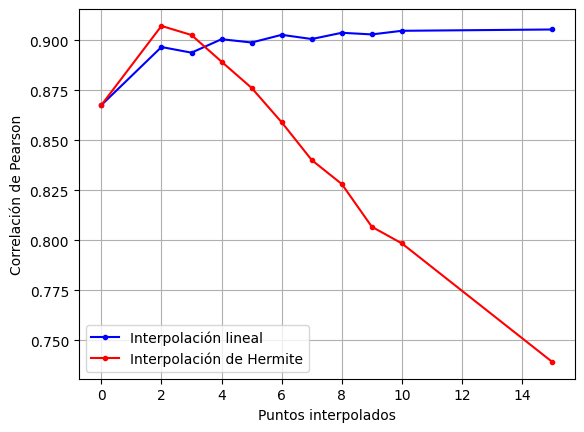

In [ ]:
def graficar_correlaciones_interpolacion(cantidad_datos, zona, lyapunov_continuo = np.load('logistic_map/lyapunov_continuo.npy') ,caotico=np.load('logistic_map/regimen_caotico.npy')):
    """
    Genera gráficas de correlación entre índice J y exponente de Lyapunov para distintas interpolaciones.

    Parámetros:
    -----------
    lyapunov_continuo : array
        Array de exponentes de Lyapunov (ya cargado previamente).
    cantidad_datos : str
        'pocos', 'muypocos' o 'muchos'
    zona : str
        'caos_regular' o 'caos'
    """

    corrs = {'corrs1': [], 'corrs2': []}
    caotico = np.load('data/caotico_henon.npy')
    lyapunov = np.load('data/lyapunov_henon.npy')
    etiquetas_x = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]

    for tipo_interp, corr_list in zip(['lineal', 'herm'], corrs.keys()):
        carpeta = f'data/interpolacion_{tipo_interp}/datos'
        archivos_en_carpeta = os.listdir(carpeta)
        for archivo in archivos_en_carpeta:
            if cantidad_datos == 'pocos' and 'pocosdatos.npy' in archivo and not 'muypocosdatos.npy' in archivo:
                pass
            elif cantidad_datos == 'muypocos' and 'muypocosdatos.npy' in archivo:
                pass
            elif cantidad_datos == 'muchos' and 'muchosdatos.npy' in archivo:
                pass
            else:
                continue

            Js = np.load(os.path.join(carpeta, archivo))

            if zona == 'caos_regular':
                correlacion, _ = pearsonr(Js, lyapunov)
            elif zona == 'caos':
                mask = ~np.isnan(caotico)
                correlacion, _ = pearsonr(Js[mask], lyapunov[mask])
            else:
                raise ValueError("zona debe ser 'caos_regular' o 'caos'")

            corrs[corr_list].append(correlacion)

    # Graficar
    plt.plot(etiquetas_x, corrs['corrs1'], label='Interpolación lineal', color='blue', marker='.')
    plt.plot(etiquetas_x, corrs['corrs2'], label='Interpolación de Hermite', color='red', marker='.')
    plt.xlabel('Puntos interpolados')
    plt.ylabel('Correlación de Pearson')
    plt.legend()
    plt.grid()
    plt.show()

graficar_correlaciones_interpolacion('muypocos','caos_regular',lyapunov,caotico)